Seasonal Agriculture Performance Analysis

Major Data Analytics Project

Domain: Agriculture

Project Theme: Seasonal Agriculture Performance
Tools: Python, Pandas, NumPy, Matplotlib, Seaborn

Problem Statement 
 
Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another. However, raw agricultural data does not clearly explain how agricultural performance changes across seasons or what patterns can be observed in different seasonal conditions. The problem is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data. 

Objective 

The primary objective of this project is to analyze agricultural data from different seasons and identify meaningful patterns, trends, relationships and differences in agricultural performance. Students should independently:  Explore and understand the dataset.   Clean and prepare the data for analysis.   Examine how agricultural performance varies across seasons.   Identify important seasonal patterns and trends.   Investigate relationships between seasonal conditions and agricultural outcomes.   Compare relevant groups within different seasons.   Identify significant differences or unusual patterns.   Apply appropriate statistical and visualization techniques.   Interpret findings based on evidence from the dataset.   Develop meaningful conclusions and data-driven recommendations. 

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')

In [3]:
df.shape

(4000, 28)

In [4]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [7]:
df.isnull().sum()

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [5]:
df['Rainfall_mm'] = df.groupby('Season')['Rainfall_mm'].transform(lambda  x: x.fillna(x.median()))
df['Soil_Moisture_pct'] = df.groupby('Season')['Soil_Moisture_pct'].transform(lambda  x: x.fillna(x.median()))

In [6]:
df = df.dropna(subset=['Yield_Tonnes_Ha'])

In [7]:
df[['Rainfall_mm', 'Soil_Moisture_pct']].isnull().sum()

Rainfall_mm          0
Soil_Moisture_pct    0
dtype: int64

In [8]:
df.shape

(3968, 28)

In [9]:
df['Yield_Tonnes_Ha'].isnull().sum()

np.int64(0)

In [10]:
print("Number of unique states:", df['State'].nunique())

Number of unique states: 8


In [11]:
print("Number of unique districts:", df['District'].nunique())
print("Number of unique crops:", df['Crop'].nunique())
print("Number of unique Season:", df['Season'].nunique())
print("Number of unique Irrigation Method:", df['Irrigation_Method'].nunique())

Number of unique districts: 10
Number of unique crops: 8
Number of unique Season: 3
Number of unique Irrigation Method: 4


In [11]:
print(df['Season'].value_counts())

Season
Kharif    1772
Rabi      1607
Zaid       589
Name: count, dtype: int64


In [12]:
#How does agricultural performance vary across seasons
season_performance = df.groupby('Season')[[
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Revenue_INR',
    'Total_Cost_INR',
    'Profit_INR'
]].mean()

print(season_performance)

        Yield_Tonnes_Ha  Production_Tonnes    Revenue_INR  Total_Cost_INR  \
Season                                                                      
Kharif         5.643973          46.440830  711441.277652   532074.152935   
Rabi           5.080498          41.337953  601825.545737   513628.294337   
Zaid           4.665942          39.146146  516662.120543   543254.517827   

           Profit_INR  
Season                 
Kharif  179367.124718  
Rabi     88197.251400  
Zaid    -26592.397284  


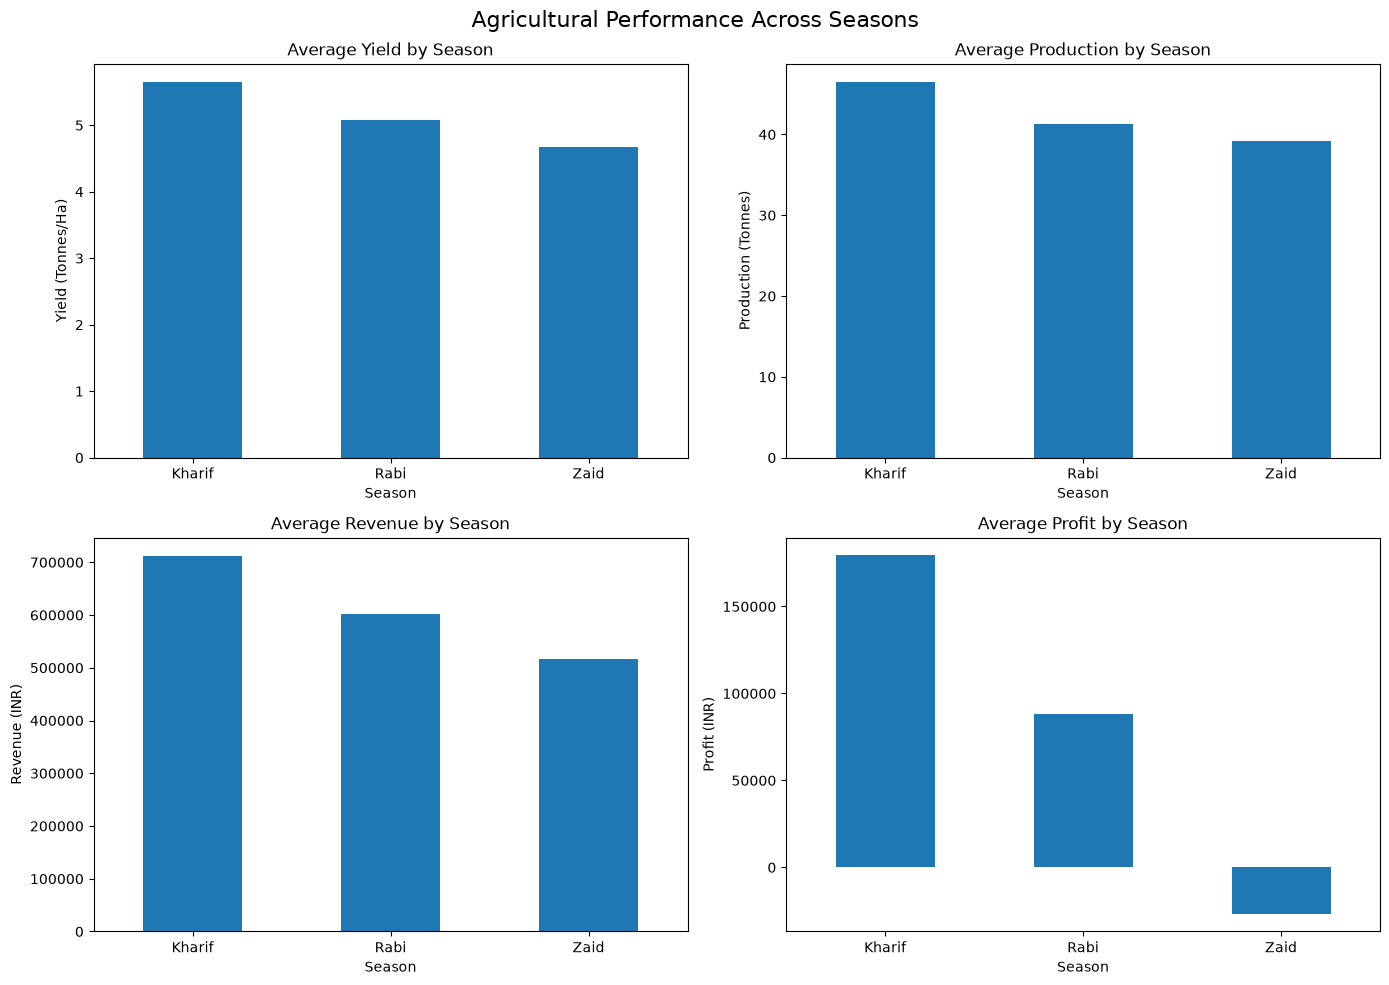

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Average Yield
season_performance['Yield_Tonnes_Ha'].plot(
    kind='bar', ax=axes[0, 0]
)
axes[0, 0].set_title('Average Yield by Season')
axes[0, 0].set_xlabel('Season')
axes[0, 0].set_ylabel('Yield (Tonnes/Ha)')
axes[0, 0].tick_params(axis='x', rotation=0)

# Average Production
season_performance['Production_Tonnes'].plot(
    kind='bar', ax=axes[0, 1]
)
axes[0, 1].set_title('Average Production by Season')
axes[0, 1].set_xlabel('Season')
axes[0, 1].set_ylabel('Production (Tonnes)')
axes[0, 1].tick_params(axis='x', rotation=0)

# Average Revenue
season_performance['Revenue_INR'].plot(
    kind='bar', ax=axes[1, 0]
)
axes[1, 0].set_title('Average Revenue by Season')
axes[1, 0].set_xlabel('Season')
axes[1, 0].set_ylabel('Revenue (INR)')
axes[1, 0].tick_params(axis='x', rotation=0)

# Average Profit
season_performance['Profit_INR'].plot(
    kind='bar', ax=axes[1, 1]
)
axes[1, 1].set_title('Average Profit by Season')
axes[1, 1].set_xlabel('Season')
axes[1, 1].set_ylabel('Profit (INR)')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.suptitle('Agricultural Performance Across Seasons', fontsize=16)
plt.tight_layout()
plt.show()

In [14]:
crop_yield = df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

print(crop_yield)

Crop
Sugarcane    46.938746
Maize         2.717130
Rice          2.439413
Wheat         2.109216
Chilli        1.540344
Groundnut     1.317924
Cotton        1.225734
Pulses        0.918198
Name: Yield_Tonnes_Ha, dtype: float64


In [15]:
season_crop_yield = df.groupby(
    ['Season', 'Crop']
)['Yield_Tonnes_Ha'].mean().unstack()

print(season_crop_yield)

Crop      Chilli    Cotton  Groundnut     Maize    Pulses      Rice  \
Season                                                                
Kharif  1.731413  1.372804   1.483646  2.966410  1.036063  2.707621   
Rabi    1.461615  1.192915   1.221445  2.614913  0.871887  2.333680   
Zaid    1.177742  0.951648   1.037778  2.297590  0.652131  1.900490   

Crop    Sugarcane     Wheat  
Season                       
Kharif  53.459120  2.255430  
Rabi    43.940394  2.058814  
Zaid    38.423922  1.748588  


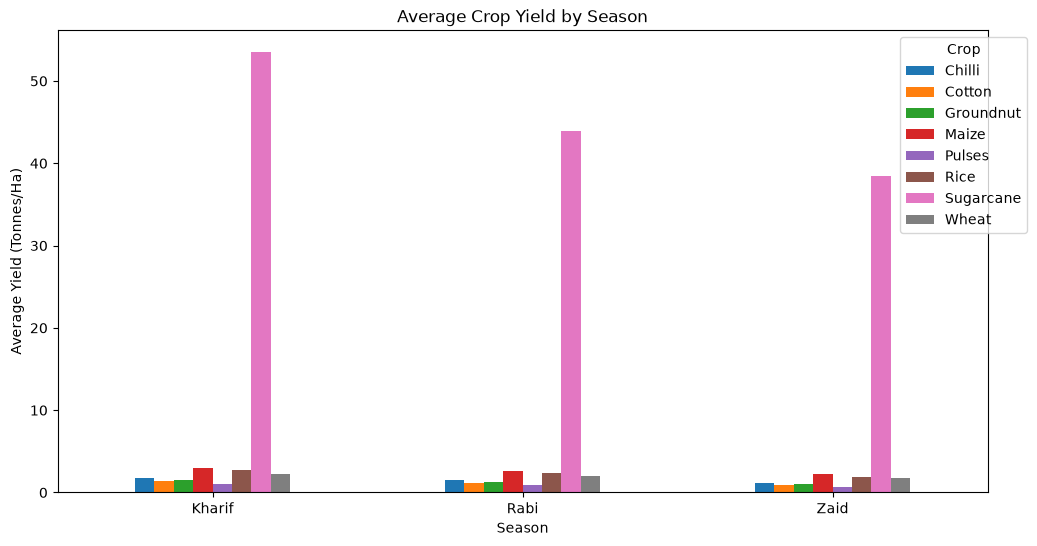

In [16]:
season_crop_yield.plot(kind='bar', figsize=(12,6))

plt.title('Average Crop Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=0)
plt.legend(title='Crop', bbox_to_anchor=(1.05, 1))
plt.show()

In [17]:
season_summary = df.groupby('Season')[[
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Soil_Moisture_pct',
    'Yield_Tonnes_Ha',
    'Water_Used_m3',
    'Profit_INR'
]].mean()

print(season_summary)

        Rainfall_mm  Avg_Temperature_C  Humidity_pct  Soil_Moisture_pct  \
Season                                                                    
Kharif   851.614814          28.448251     71.843962          31.200790   
Rabi     436.229434          23.496204     57.923149          24.075544   
Zaid     298.673175          31.050594     51.988455          19.161969   

        Yield_Tonnes_Ha  Water_Used_m3     Profit_INR  
Season                                                 
Kharif         5.643973    6094.046275  179367.124718  
Rabi           5.080498    5837.238955   88197.251400  
Zaid           4.665942    6423.076401  -26592.397284  


In [18]:
weather_by_season = df.groupby('Season')[[
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Soil_Moisture_pct',
    'Soil_pH'
]].mean()

print(weather_by_season)

        Rainfall_mm  Avg_Temperature_C  Humidity_pct  Soil_Moisture_pct  \
Season                                                                    
Kharif   851.614814          28.448251     71.843962          31.200790   
Rabi     436.229434          23.496204     57.923149          24.075544   
Zaid     298.673175          31.050594     51.988455          19.161969   

         Soil_pH  
Season            
Kharif  6.728713  
Rabi    6.672813  
Zaid    6.692683  


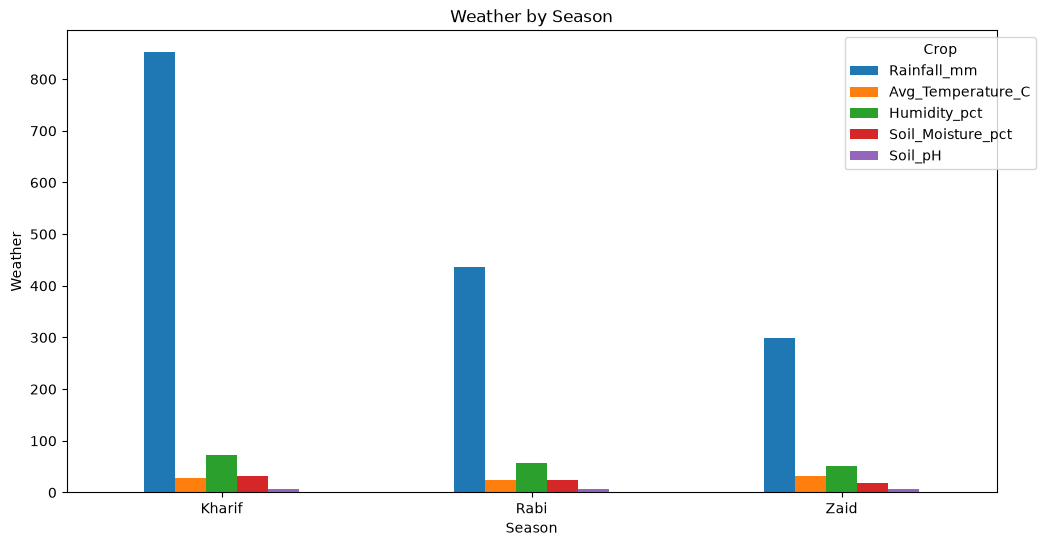

In [19]:
weather_by_season.plot(kind='bar', figsize=(12,6))

plt.title('Weather by Season')
plt.xlabel('Season')
plt.ylabel('Weather')
plt.xticks(rotation=0)
plt.legend(title='Crop', bbox_to_anchor=(1.05, 1))
plt.show()

The analysis shows clear seasonal variation in environmental conditions. Kharif is characterized by higher rainfall, soil moisture, and humidity, while Zaid experiences higher temperatures. In contrast, soil pH remains relatively stable across seasons, indicating limited seasonal variation in soil acidity or alkalinity.

In [20]:
#Are there noticeable variations in resource usage across seasons?
water_by_season = df.groupby('Season')['Water_Used_m3'].mean()

print(water_by_season)

Season
Kharif    6094.046275
Rabi      5837.238955
Zaid      6423.076401
Name: Water_Used_m3, dtype: float64


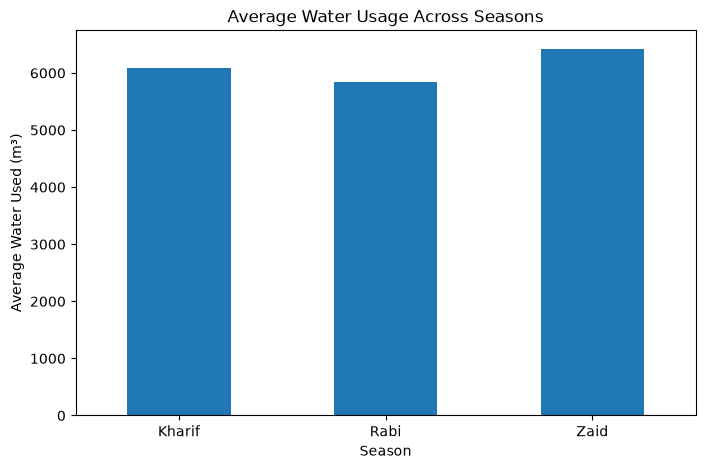

In [21]:
water_by_season.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Average Water Usage Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Water Used (m³)')
plt.xticks(rotation=0)
plt.show()

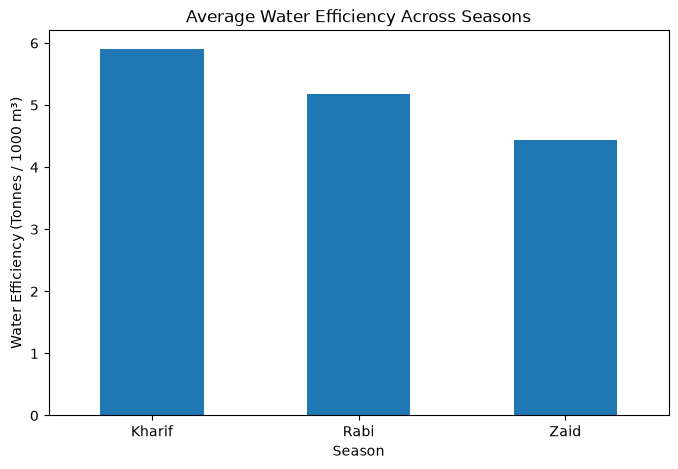

In [22]:
efficiency_by_season = df.groupby('Season')['Water_Efficiency_t_per_1000m3'].mean()

efficiency_by_season.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Average Water Efficiency Across Seasons')
plt.xlabel('Season')
plt.ylabel('Water Efficiency (Tonnes / 1000 m³)')
plt.xticks(rotation=0)
plt.show()

In [23]:
resource_by_season = df.groupby('Season')[[
    'Water_Used_m3',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha'
]].mean()

print(resource_by_season)

        Water_Used_m3  Fertilizer_kg_ha  Pesticide_Litre_ha
Season                                                     
Kharif    6094.046275        187.041027            5.078736
Rabi      5837.238955        185.282016            5.025669
Zaid      6423.076401        184.233447            5.162598


Resource consumption varies across seasons. Zaid records the highest average water and pesticide usage, while Kharif has the highest fertilizer application. Rabi shows comparatively lower usage across these resources. The variation is most noticeable in water consumption

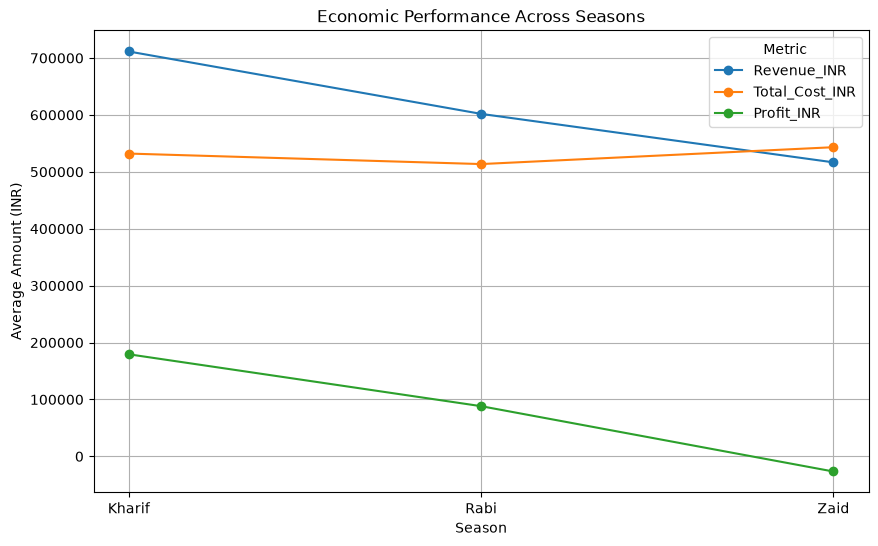

In [24]:
economic_by_season = df.groupby('Season')[[
    'Revenue_INR',
    'Total_Cost_INR',
    'Profit_INR'
]].mean()

economic_by_season.plot(
    kind='line',
    marker='o',
    figsize=(10, 6)
)

plt.title('Economic Performance Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Amount (INR)')
plt.xticks(range(len(economic_by_season.index)), economic_by_season.index)
plt.legend(title='Metric')
plt.grid(True)
plt.show()

In [26]:
state_season_yield = df.groupby(
    ['State', 'Season']
)['Yield_Tonnes_Ha'].mean().unstack()

print(state_season_yield)

Season            Kharif      Rabi      Zaid
State                                       
Andhra Pradesh  5.693431  3.488069  4.480238
Gujarat         6.338416  5.517245  4.101970
Karnataka       6.523689  4.609655  6.623243
Madhya Pradesh  6.004133  3.800000  5.539194
Maharashtra     5.447014  5.501927  2.285352
Punjab          4.100633  8.609355  5.909610
Tamil Nadu      5.520534  4.555539  4.097746
Telangana       5.568798  4.831649  4.278333


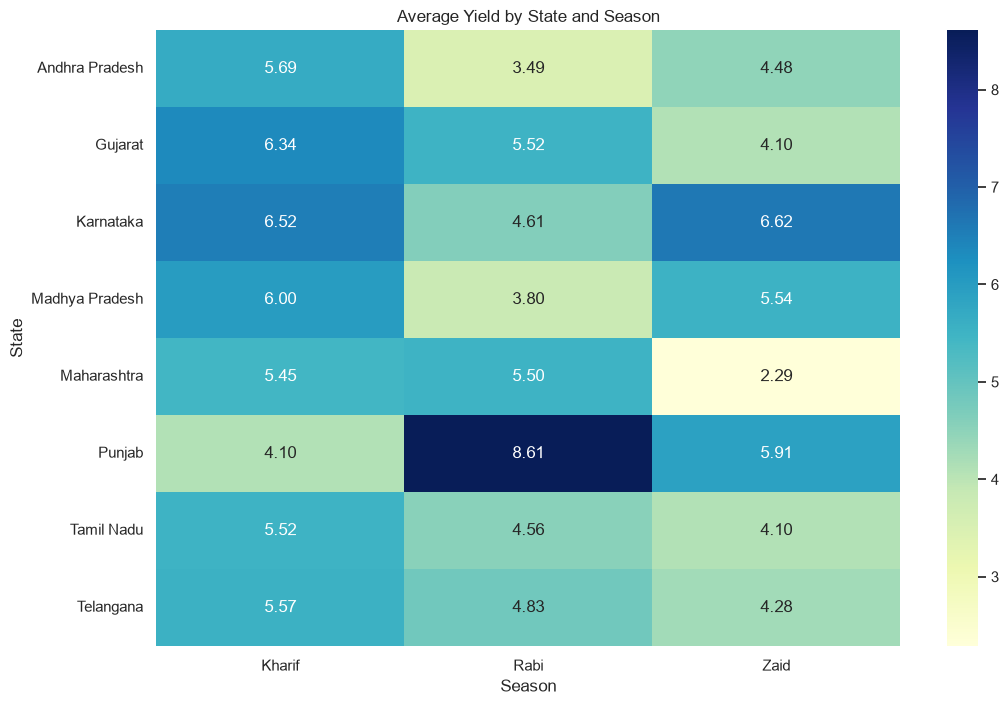

In [27]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    state_season_yield,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Average Yield by State and Season')
plt.xlabel('Season')
plt.ylabel('State')
plt.show()

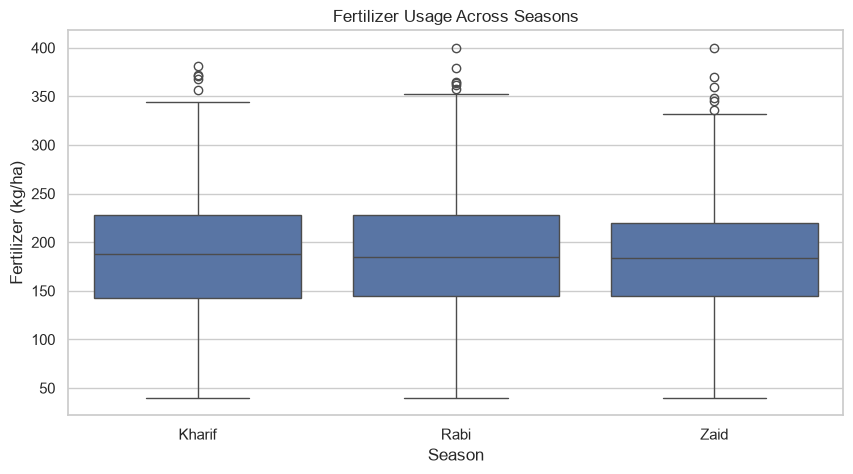

In [29]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x='Season',
    y='Fertilizer_kg_ha'
)

plt.title('Fertilizer Usage Across Seasons')
plt.xlabel('Season')
plt.ylabel('Fertilizer (kg/ha)')
plt.show()

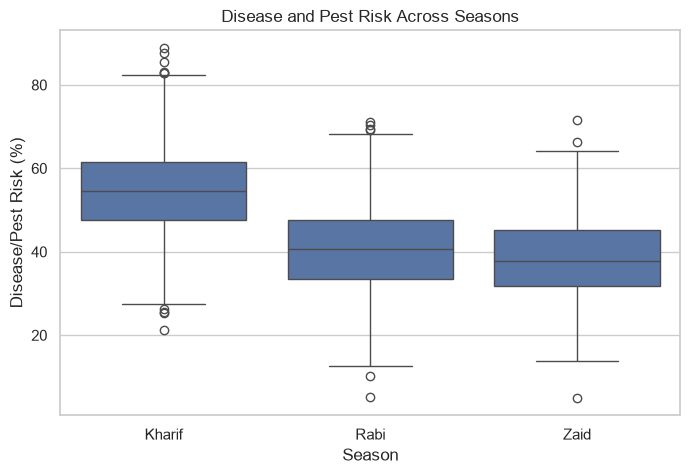

In [30]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Season',
    y='Disease_Pest_Risk_pct'
)

plt.title('Disease and Pest Risk Across Seasons')
plt.xlabel('Season')
plt.ylabel('Disease/Pest Risk (%)')
plt.show()

In [31]:
final_season_summary = df.groupby('Season')[[
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Soil_Moisture_pct',
    'Yield_Tonnes_Ha',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Profit_INR'
]].mean()

print(final_season_summary.round(2))

        Rainfall_mm  Avg_Temperature_C  Humidity_pct  Soil_Moisture_pct  \
Season                                                                    
Kharif       851.61              28.45         71.84              31.20   
Rabi         436.23              23.50         57.92              24.08   
Zaid         298.67              31.05         51.99              19.16   

        Yield_Tonnes_Ha  Water_Used_m3  Water_Efficiency_t_per_1000m3  \
Season                                                                  
Kharif             5.64        6094.05                           5.91   
Rabi               5.08        5837.24                           5.18   
Zaid               4.67        6423.08                           4.44   

        Fertilizer_kg_ha  Pesticide_Litre_ha  Profit_INR  
Season                                                    
Kharif            187.04                5.08   179367.12  
Rabi              185.28                5.03    88197.25  
Zaid              184.

In [32]:
irrigation_season = pd.crosstab(df['Season'], df['Irrigation_Method'])
print(irrigation_season)

Irrigation_Method  Drip  Flood  Rainfed  Sprinkler
Season                                            
Kharif              405    586      461        320
Rabi                362    520      436        289
Zaid                140    190      140        119


In [33]:
nutrients_by_season = df.groupby('Season')[[
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha'
]].mean()

print(nutrients_by_season.round(2))

        Nitrogen_kg_ha  Phosphorus_kg_ha  Potassium_kg_ha
Season                                                   
Kharif          119.96             58.09           105.32
Rabi            120.31             57.32           103.81
Zaid            120.65             58.28           105.36
